# AML Final Project — Tumor Microenvironment RBF Network Classifier
**MATH 5384 Advanced Machine Learning | Habib Ogunsola | Lamar University**

This notebook trains and evaluates an RBF network on a synthetic tumor microenvironment dataset.
The dataset contains two classes:
- **C1 (label=0)** — Viable tumour rim (minority, ~200 samples)
- **C2 (label=1)** — Immune/stromal infiltrate (majority, ~800 samples)

Architecture: RBFLayer (k-means seeded) → Linear(k→32) + BN + ReLU → Linear(32→16) + ReLU → Linear(16→1)

## 1. Imports

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    pairwise_distances, classification_report,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, f1_score,
    roc_curve, precision_recall_curve,
)
import copy

np.random.seed(42)
torch.manual_seed(42)

# project colour palette
C1_COLOR = '#c0392b'
C2_COLOR = '#2980b9'

OUTPUT_DIR = 'aml-final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('PyTorch:', torch.__version__)
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch: 2.9.0
Device: cpu


## 2. Data

In [2]:
DATA_PATH = 'data-generation/tumor_dataset.csv'
df = pd.read_csv(DATA_PATH)
X = df[['x1', 'x2']].values
y = df['label'].values

print(f'Total samples : {len(df)}')
print(f'C1 (label=0)  : {(y==0).sum()}  ({100*(y==0).mean():.1f}%)')
print(f'C2 (label=1)  : {(y==1).sum()}  ({100*(y==1).mean():.1f}%)')
df.describe()

Total samples : 1000
C1 (label=0)  : 200  (20.0%)
C2 (label=1)  : 800  (80.0%)


,x1,x2,label
count,1000.000000,1000.000000,1000.0000
mean,0.750841,0.622825,0.8000
std,1.102615,1.113857,0.4002
min,-1.934830,-2.268383,0.0000
25%,-0.181175,-0.285069,1.0000
50%,0.877812,0.665298,1.0000
75%,1.640010,1.574431,1.0000
max,3.113440,2.946909,1.0000


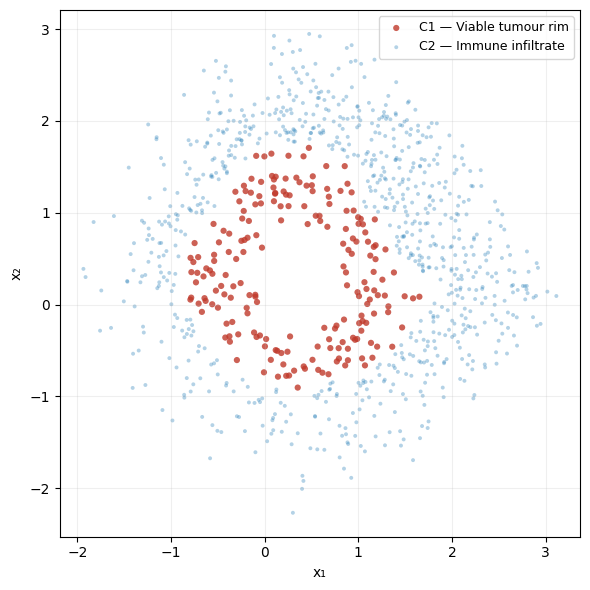

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[y==0, 0], X[y==0, 1], c=C1_COLOR, s=20, alpha=0.8,
           edgecolors='none', label='C1 — Viable tumour rim')
ax.scatter(X[y==1, 0], X[y==1, 1], c=C2_COLOR, s=8,  alpha=0.35,
           edgecolors='none', label='C2 — Immune infiltrate')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_raw_data.png', dpi=150)
plt.show()

In [4]:
# 70 / 10 / 20 train–val–test split, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, stratify=y_train, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')
print(f'Train C1/C2: {(y_train==0).sum()} / {(y_train==1).sum()}')
print(f'Test  C1/C2: {(y_test ==0).sum()} / {(y_test ==1).sum()}')

Train: 700  Val: 100  Test: 200
Train C1/C2: 140 / 560
Test  C1/C2: 40 / 160


## 3. Model

In [5]:
class RBFLayer(nn.Module):
    """
    phi_i(x) = exp(-gamma_i * ||x - c_i||^2)
    Centers and log-gammas are learnable parameters.
    """
    def __init__(self, in_features: int, n_centers: int):
        super().__init__()
        self.centers   = nn.Parameter(torch.empty(n_centers, in_features))
        self.log_gamma = nn.Parameter(torch.zeros(n_centers))
        nn.init.normal_(self.centers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        diff    = x.unsqueeze(1) - self.centers.unsqueeze(0)   # (B, K, D)
        dist_sq = (diff ** 2).sum(-1)                          # (B, K)
        gamma   = torch.exp(self.log_gamma)
        return torch.exp(-gamma * dist_sq)


class TumorClassifier(nn.Module):
    """
    RBFLayer → Linear(k→32)+BN+ReLU+Dropout → Linear(32→16)+ReLU → Linear(16→1)
    """
    def __init__(self, n_centers: int = 20, dropout: float = 0.3):
        super().__init__()
        self.rbf     = RBFLayer(in_features=2, n_centers=n_centers)
        self.hidden1 = nn.Linear(n_centers, 32)
        self.bn1     = nn.BatchNorm1d(32)
        self.hidden2 = nn.Linear(32, 16)
        self.out     = nn.Linear(16, 1)
        self.drop    = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.rbf(x)
        x = torch.relu(self.bn1(self.hidden1(x)))
        x = self.drop(x)
        x = torch.relu(self.hidden2(x))
        return self.out(x)

    def freeze_centers(self):   self.rbf.centers.requires_grad_(False)
    def unfreeze_centers(self): self.rbf.centers.requires_grad_(True)


def init_centers_from_kmeans(rbf_layer, X_train, seed=42):
    K = rbf_layer.centers.shape[0]
    km = KMeans(n_clusters=K, random_state=seed, n_init=15)
    km.fit(X_train)
    centers = km.cluster_centers_
    D = pairwise_distances(centers)
    np.fill_diagonal(D, np.inf)
    sigma      = D.min(axis=1).mean()
    gamma_init = 1.0 / (2.0 * sigma ** 2)
    with torch.no_grad():
        rbf_layer.centers.copy_(torch.tensor(centers, dtype=torch.float32))
        rbf_layer.log_gamma.fill_(float(np.log(gamma_init)))
    return km

print('Model and RBFLayer defined.')

Model and RBFLayer defined.


## 4. Training

In [6]:
def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def run_epoch(model, loader, criterion, optimizer, device, train):
    model.train(train)
    total_loss, preds_all, labels_all = 0.0, [], []
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb).squeeze(1)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(yb)
            preds_all.append((logits.detach() > 0).cpu().numpy())
            labels_all.append(yb.cpu().numpy())
    preds  = np.concatenate(preds_all)
    labels = np.concatenate(labels_all)
    return total_loss / len(labels), f1_score(labels, preds, average='macro', zero_division=0)


def train_model(
    X_train, y_train, X_val, y_val, *,
    n_centers=20, warmup_epochs=20, max_epochs=300,
    batch_size=64, lr=1e-3, weight_decay=1e-4,
    dropout=0.3, patience=30, seed=42,
):
    torch.manual_seed(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = TumorClassifier(n_centers=n_centers, dropout=dropout).to(device)
    print(f'Running k-means (k={n_centers}) …')
    km = init_centers_from_kmeans(model.rbf, X_train, seed=seed)

    n_neg = (y_train == 0).sum(); n_pos = (y_train == 1).sum()
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_loader = make_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader   = make_loader(X_val,   y_val,   batch_size, shuffle=False)

    model.freeze_centers()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=15, factor=0.5, min_lr=1e-5)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1, best_weights, no_imp = -np.inf, None, 0

    print(f'{"Epoch":>6}  {"TrLoss":>8}  {"TrF1":>7}  {"VaLoss":>8}  {"VaF1":>7}  Note')
    print('-' * 58)

    for epoch in range(1, max_epochs + 1):
        if epoch == warmup_epochs + 1:
            model.unfreeze_centers()
            for g in optimizer.param_groups:
                g['params'] = list(filter(lambda p: p.requires_grad, model.parameters()))

        tr_loss, tr_f1 = run_epoch(model, train_loader, criterion, optimizer, device, True)
        va_loss, va_f1 = run_epoch(model, val_loader,   criterion, optimizer, device, False)
        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_f1'].append(tr_f1);    history['val_f1'].append(va_f1)
        scheduler.step(va_f1)

        note = ''
        if va_f1 > best_val_f1:
            best_val_f1 = va_f1; best_weights = copy.deepcopy(model.state_dict())
            no_imp = 0; note = '✓ best'
        else:
            no_imp += 1
            if no_imp >= patience:
                note = '→ early stop'
                print(f'{epoch:>6}  {tr_loss:>8.4f}  {tr_f1:>7.4f}  {va_loss:>8.4f}  {va_f1:>7.4f}  {note}')
                break

        if epoch % 10 == 0 or note:
            print(f'{epoch:>6}  {tr_loss:>8.4f}  {tr_f1:>7.4f}  {va_loss:>8.4f}  {va_f1:>7.4f}  {note}')

    model.load_state_dict(best_weights)
    print(f'\nBest val macro-F1: {best_val_f1:.4f}')
    return model, history, km

print('Training functions defined.')

Training functions defined.


In [7]:
model, history, km = train_model(
    X_train, y_train, X_val, y_val,
    n_centers=20,
    warmup_epochs=20,
    max_epochs=300,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    dropout=0.3,
    patience=30,
    seed=42,
)

Running k-means (k=20) …


 Epoch    TrLoss     TrF1    VaLoss     VaF1  Note
----------------------------------------------------------
     1    0.2703   0.5030    0.2744   0.4295  ✓ best
     2    0.2568   0.6445    0.2668   0.7572  ✓ best
     3    0.2431   0.7006    0.2506   0.8075  ✓ best
     4    0.2238   0.7348    0.2247   0.8513  ✓ best


     6    0.1767   0.7961    0.1583   0.8667  ✓ best
     7    0.1492   0.8224    0.1281   0.9556  ✓ best
     8    0.1239   0.8646    0.1007   0.9699  ✓ best
     9    0.0998   0.8960    0.0778   0.9847  ✓ best
    10    0.0794   0.9213    0.0626   0.9847  


    20    0.0320   0.9533    0.0217   0.9847  
    30    0.0226   0.9780    0.0240   0.9688  


    39    0.0148   0.9846    0.0218   0.9688  → early stop

Best val macro-F1: 0.9847


## 5. Results

In [8]:
def predict(model, X):
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32).to(device)).squeeze(1)
    probs = torch.sigmoid(logits).cpu().numpy()
    return (probs > 0.5).astype(int), probs

tr_preds, tr_probs = predict(model, X_train)
te_preds, te_probs = predict(model, X_test)

print('── Per-class metrics (test set) ──')
print(classification_report(
    y_test, te_preds,
    target_names=['C1 tumour rim (minority)', 'C2 immune ring (majority)'],
    digits=4,
))

── Per-class metrics (test set) ──
                           precision    recall  f1-score   support

 C1 tumour rim (minority)     0.7358    0.9750    0.8387        40
C2 immune ring (majority)     0.9932    0.9125    0.9511       160

                 accuracy                         0.9250       200
                macro avg     0.8645    0.9437    0.8949       200
             weighted avg     0.9417    0.9250    0.9287       200



In [9]:
tr_roc = roc_auc_score(y_train, tr_probs)
te_roc = roc_auc_score(y_test,  te_probs)
tr_pr  = average_precision_score(y_train, tr_probs)
te_pr  = average_precision_score(y_test,  te_probs)
tr_f1  = f1_score(y_train, tr_preds, average='macro', zero_division=0)
te_f1  = f1_score(y_test,  te_preds, average='macro', zero_division=0)

print('── AUC & F1 summary ──')
print(f'{"Metric":<14} {"Train":>8}  {"Test":>8}  {"Gap":>8}  Flag')
print('-' * 52)
for name, tr, te in [('Macro F1', tr_f1, te_f1), ('ROC-AUC', tr_roc, te_roc), ('PR-AUC', tr_pr, te_pr)]:
    gap  = tr - te
    flag = '⚠ overfit?' if gap > 0.05 else 'ok'
    print(f'{name:<14} {tr:>8.4f}  {te:>8.4f}  {gap:>+8.4f}  {flag}')

── AUC & F1 summary ──
Metric            Train      Test       Gap  Flag
----------------------------------------------------
Macro F1         0.9318    0.8949   +0.0369  ok
ROC-AUC          0.9984    0.9934   +0.0049  ok
PR-AUC           0.9996    0.9984   +0.0012  ok


## 6. Plots

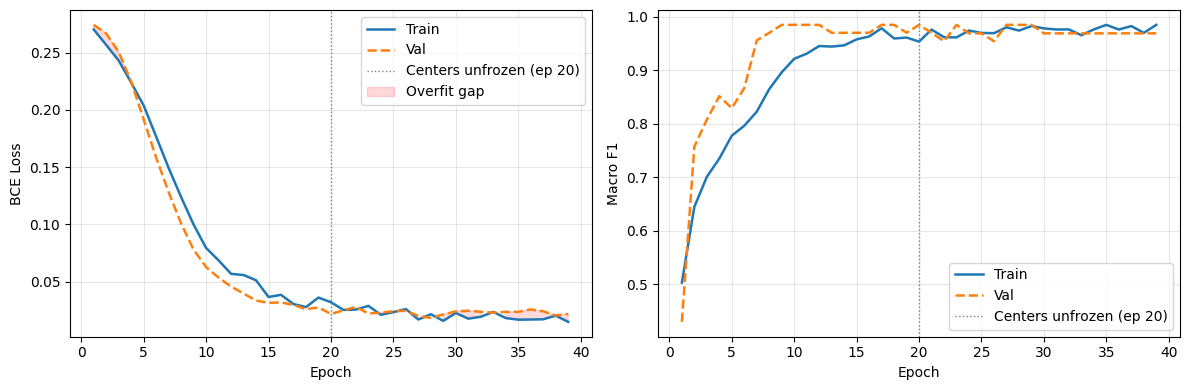

In [10]:
# Learning curves
epochs = range(1, len(history['train_loss']) + 1)
warmup_epochs = 20

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tr_key, va_key, ylabel in zip(
    axes,
    ['train_loss', 'train_f1'],
    ['val_loss',   'val_f1'],
    ['BCE Loss',   'Macro F1'],
):
    ax.plot(epochs, history[tr_key], label='Train', linewidth=1.8)
    ax.plot(epochs, history[va_key], label='Val',   linewidth=1.8, linestyle='--')
    ax.axvline(warmup_epochs, color='grey', linestyle=':', linewidth=1,
               label=f'Centers unfrozen (ep {warmup_epochs})')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

tr_loss = np.array(history['train_loss'])
va_loss = np.array(history['val_loss'])
gap     = va_loss - tr_loss
axes[0].fill_between(epochs, tr_loss, va_loss, where=(gap > 0),
                     alpha=0.15, color='red', label='Overfit gap')
axes[0].legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_learning_curves.png', dpi=150)
plt.show()

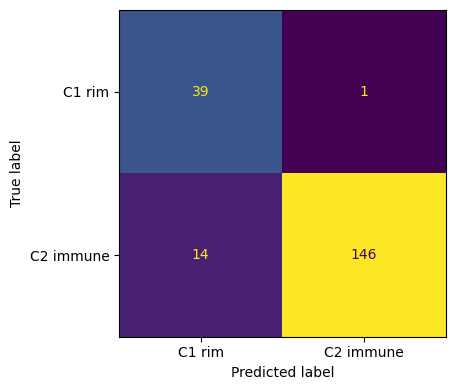

In [11]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, te_preds,
    display_labels=['C1 rim', 'C2 immune'],
    ax=ax, colorbar=False,
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_confusion_matrix.png', dpi=150)
plt.show()

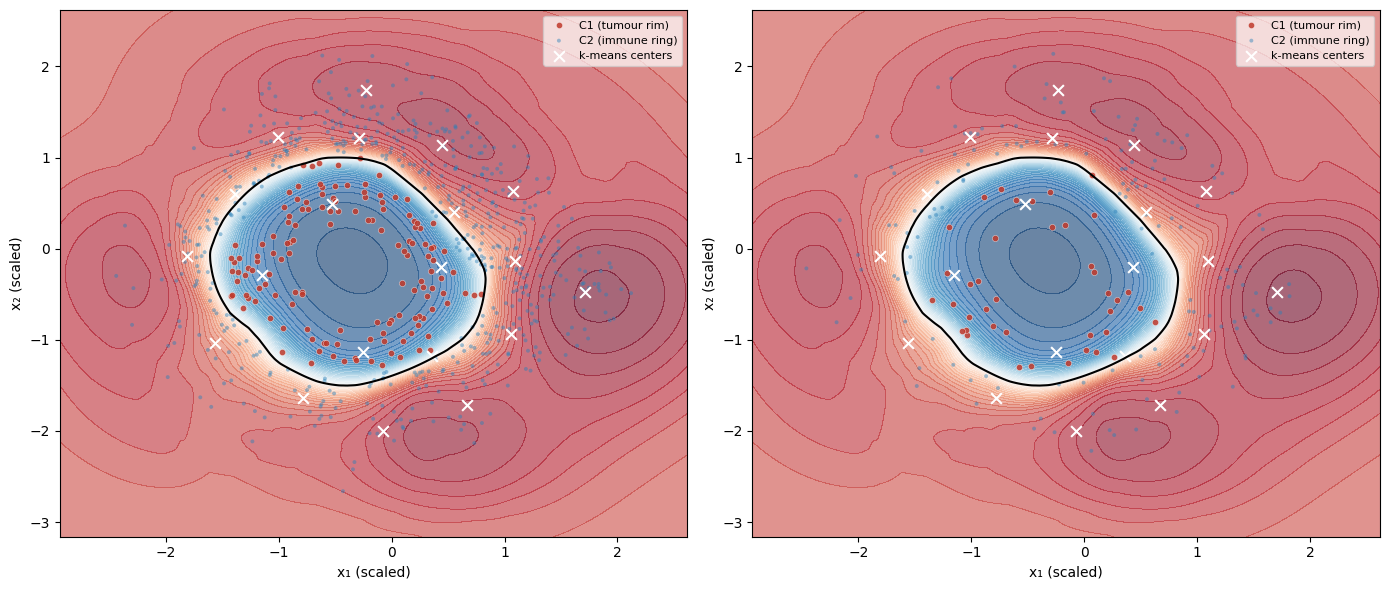

In [12]:
# Decision boundary — train and test side by side
device = next(model.parameters()).device
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

model.eval()
with torch.no_grad():
    logits = model(torch.tensor(grid, dtype=torch.float32).to(device)).squeeze(1)
Z = torch.sigmoid(logits).cpu().numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, X_pts, y_pts, title in zip(
    axes,
    [X_train, X_test],
    [y_train, y_test],
    ['Train set', 'Test set'],
):
    ax.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
    ax.contour( xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5)
    mask0 = y_pts == 0
    ax.scatter(X_pts[mask0,  0], X_pts[mask0,  1], c=C1_COLOR, s=20, alpha=0.85,
               edgecolors='white', linewidths=0.3, label='C1 (tumour rim)')
    ax.scatter(X_pts[~mask0, 0], X_pts[~mask0, 1], c=C2_COLOR, s=8,  alpha=0.45,
               edgecolors='none', label='C2 (immune ring)')
    if km is not None:
        ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                   marker='x', s=60, c='white', linewidths=1.5, label='k-means centers')
    ax.set_xlabel('x₁ (scaled)'); ax.set_ylabel('x₂ (scaled)')
    ax.legend(fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_decision_boundary.png', dpi=150)
plt.show()


── Sweep k=5 ──
Running k-means (k=5) …
 Epoch    TrLoss     TrF1    VaLoss     VaF1  Note
----------------------------------------------------------
     1    0.2727   0.5528    0.2739   0.7137  ✓ best
     3    0.2524   0.7156    0.2556   0.7305  ✓ best
     4    0.2372   0.7443    0.2367   0.7401  ✓ best
     5    0.2209   0.7723    0.2136   0.7763  ✓ best
     6    0.2048   0.7898    0.1902   0.8026  ✓ best
     7    0.1845   0.7934    0.1664   0.8289  ✓ best
     8    0.1599   0.8372    0.1442   0.8996  ✓ best


    10    0.1220   0.8714    0.1067   0.8748  
    13    0.0799   0.9082    0.0720   0.9027  ✓ best
    14    0.0790   0.9093    0.0636   0.9153  ✓ best
    16    0.0753   0.8974    0.0531   0.9283  ✓ best
    20    0.0494   0.9171    0.0445   0.9417  ✓ best


    24    0.0519   0.9175    0.0390   0.9556  ✓ best
    30    0.0434   0.9115    0.0373   0.9283  
    35    0.0372   0.9367    0.0345   0.9688  ✓ best


    40    0.0359   0.9370    0.0307   0.9540  
    46    0.0326   0.9588    0.0265   0.9699  ✓ best
    50    0.0338   0.9504    0.0281   0.9556  


    60    0.0269   0.9567    0.0257   0.9699  
    66    0.0413   0.9341    0.0259   0.9688  → early stop

Best val macro-F1: 0.9699

── Sweep k=10 ──
Running k-means (k=10) …


...

 Epoch    TrLoss     TrF1    VaLoss     VaF1  Note
----------------------------------------------------------
     1    0.2665   0.3408    0.2745   0.1667  ✓ best
     2    0.2480   0.5046    0.2653   0.4000  ✓ best
     3    0.2282   0.6341    0.2444   0.6923  ✓ best
     4    0.2053   0.7202    0.2105   0.7335  ✓ best
     5    0.1774   0.7669    0.1714   0.8016  ✓ best
     6    0.1480   0.8240    0.1348   0.8784  ✓ best
     7    0.1200   0.8640    0.1059   0.9283  ✓ best
     8    0.0949   0.9251    0.0834   0.9847  ✓ best


    10    0.0690   0.9305    0.0527   0.9847  
    20    0.0214   0.9718    0.0316   0.9540  


    28    0.0127   0.9803    0.0293   0.9540  → early stop

Best val macro-F1: 0.9847

── Sweep k=40 ──
Running k-means (k=40) …
 Epoch    TrLoss     TrF1    VaLoss     VaF1  Note
----------------------------------------------------------
     1    0.2837   0.4655    0.2785   0.4444  ✓ best
     3    0.2380   0.7759    0.2474   0.9025  ✓ best
     4    0.2088   0.7881    0.2109   0.9259  ✓ best


     8    0.0999   0.9183    0.0862   0.9699  ✓ best
    10    0.0686   0.9376    0.0574   0.9847  ✓ best


    20    0.0163   0.9912    0.0273   0.9522  
    30    0.0106   0.9978    0.0260   0.9688  → early stop

Best val macro-F1: 0.9847


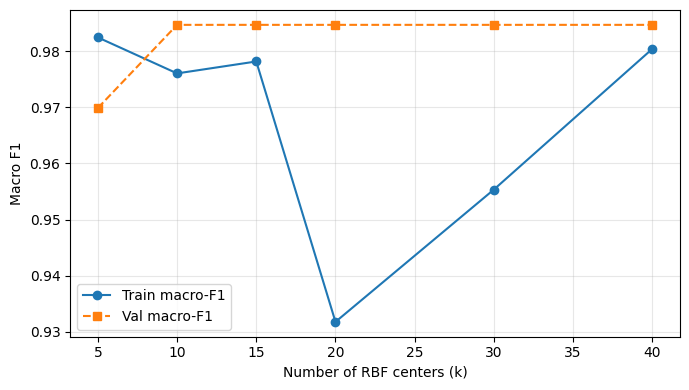


Sweep results:
   k    Train F1      Val F1
   5      0.9824      0.9699
  10      0.9760      0.9847
  15      0.9781      0.9847
  20      0.9318      0.9847
  30      0.9553      0.9847
  40      0.9804      0.9847


In [13]:
# Complexity sweep — RBF center count vs macro-F1
center_grid = [5, 10, 15, 20, 30, 40]
tr_f1s, va_f1s = [], []

for k in center_grid:
    print(f'\n── Sweep k={k} ──')
    m, h, _ = train_model(
        X_train, y_train, X_val, y_val,
        n_centers=k, warmup_epochs=20, max_epochs=200,
        batch_size=64, lr=1e-3, weight_decay=1e-4,
        dropout=0.3, patience=20, seed=42,
    )
    p_tr, _ = predict(m, X_train)
    p_va, _ = predict(m, X_val)
    tr_f1s.append(f1_score(y_train, p_tr, average='macro', zero_division=0))
    va_f1s.append(f1_score(y_val,   p_va, average='macro', zero_division=0))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(center_grid, tr_f1s, 'o-',  label='Train macro-F1')
ax.plot(center_grid, va_f1s, 's--', label='Val macro-F1')
ax.set_xlabel('Number of RBF centers (k)')
ax.set_ylabel('Macro F1')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_complexity_sweep.png', dpi=150)
plt.show()

print('\nSweep results:')
print(f'{"k":>4}  {"Train F1":>10}  {"Val F1":>10}')
for k, tr, va in zip(center_grid, tr_f1s, va_f1s):
    print(f'{k:>4}  {tr:>10.4f}  {va:>10.4f}')

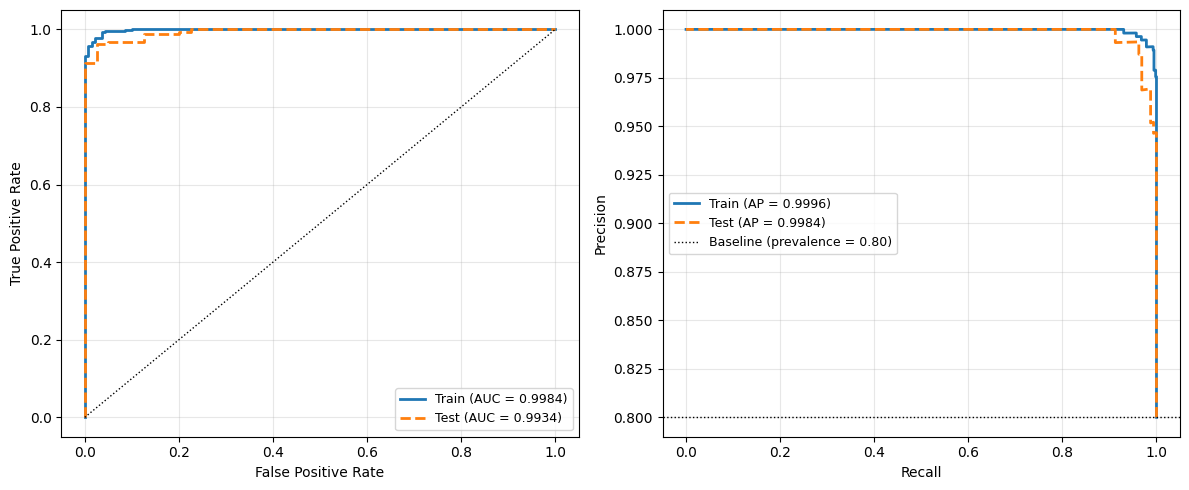

In [14]:
# ROC and Precision-Recall curves — train vs test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for probs, labels, tag, ls, lw in [
    (tr_probs, y_train, 'Train', '-',  2.0),
    (te_probs, y_test,  'Test',  '--', 2.0),
]:
    fpr, tpr, _   = roc_curve(labels, probs)
    prec, rec, _  = precision_recall_curve(labels, probs)
    auc_roc = roc_auc_score(labels, probs)
    auc_pr  = average_precision_score(labels, probs)

    axes[0].plot(fpr, tpr, linestyle=ls, linewidth=lw,
                 label=f'{tag} (AUC = {auc_roc:.4f})')
    axes[1].plot(rec, prec, linestyle=ls, linewidth=lw,
                 label=f'{tag} (AP = {auc_pr:.4f})')

axes[0].plot([0, 1], [0, 1], 'k:', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

baseline_pr = (y_test == 1).mean()
axes[1].axhline(baseline_pr, color='k', linestyle=':', linewidth=1,
                label=f'Baseline (prevalence = {baseline_pr:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6_roc_pr.png', dpi=150)
plt.show()